# Day 7: one-time final-test evaluation

This notebook reads the locked aggregate Day 7 artefacts. It does not load final-test rows, rescore the model, refit anything or revise the frozen threshold.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
lock = json.loads((REPORTS / 'day7_final_decision_lock.json').read_text())
metrics = json.loads((REPORTS / 'day7_final_test_metrics.json').read_text())
comparison = pd.read_csv(REPORTS / 'day7_validation_test_comparison.csv')
assert lock['created_before_final_test_outcomes_loaded']
assert metrics['model_sha256_before'] == metrics['model_sha256_after'] == lock['frozen_model_sha256']
assert not metrics['post_test_decision_changed']
lock

{'created_before_final_test_outcomes_loaded': True,
 'final_test_evaluation_authorised': True,
 'frozen_model_path': 'models/day4_random_forest_pipeline.joblib',
 'frozen_model_sha256': '1d52eed5ae717e3e0bc09d319362263fcebcfb9f691a23951df32ac5c935037e',
 'frozen_preprocessing': 'The preprocessing embedded in the frozen Random Forest pipeline is immutable.',
 'frozen_threshold': 0.1912638431828811,
 'lock_date': '2026-07-24',
 'no_superiority_claim': True,
 'paired_rf_minus_xgboost_ap_uncertainty_interval': [-0.0075220545,
  0.0137943885],
 'post_test_change_prohibition': 'After final-test results are viewed, the model, threshold and preprocessing must not be changed, refitted, tuned, recalibrated or selected again.',
 'selection_basis': 'highest numerical validation Average Precision',
 'status': 'locked before one-time final-test evaluation'}

## Aggregate final-test metrics

In [2]:
pd.Series({
    'Rows': metrics['rows'],
    'Class prevalence': metrics['class_prevalence'],
    'ROC-AUC': metrics['roc_auc'],
    'Average Precision': metrics['average_precision'],
    'Frozen threshold': metrics['frozen_threshold'],
    'Precision': metrics['precision'],
    'Recall': metrics['recall'],
    'F1': metrics['f1'],
    'False-positive rate': metrics['false_positive_rate'],
    'Proportion flagged': metrics['proportion_flagged'],
})

Rows                   6000.000000
Class prevalence          0.221167
ROC-AUC                   0.779397
Average Precision         0.557033
Frozen threshold          0.191264
Precision                 0.406195
Recall                    0.691786
F1                        0.511848
False-positive rate       0.287182
Proportion flagged        0.376667
dtype: float64

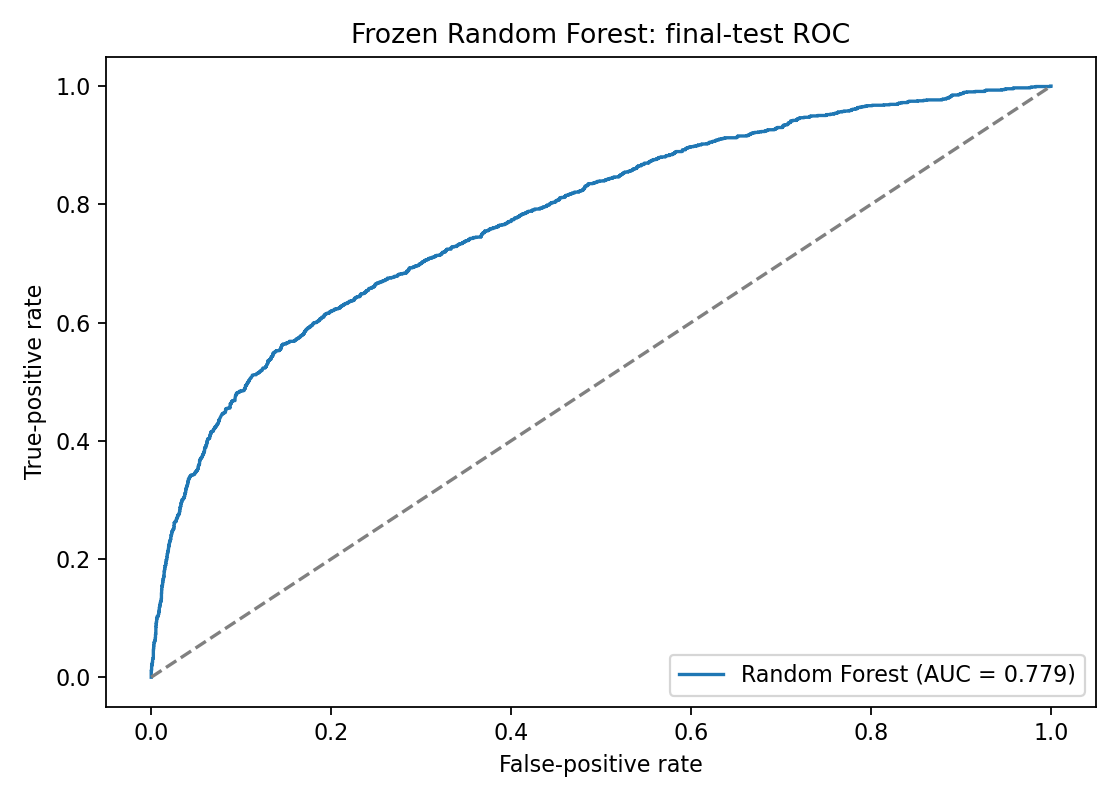

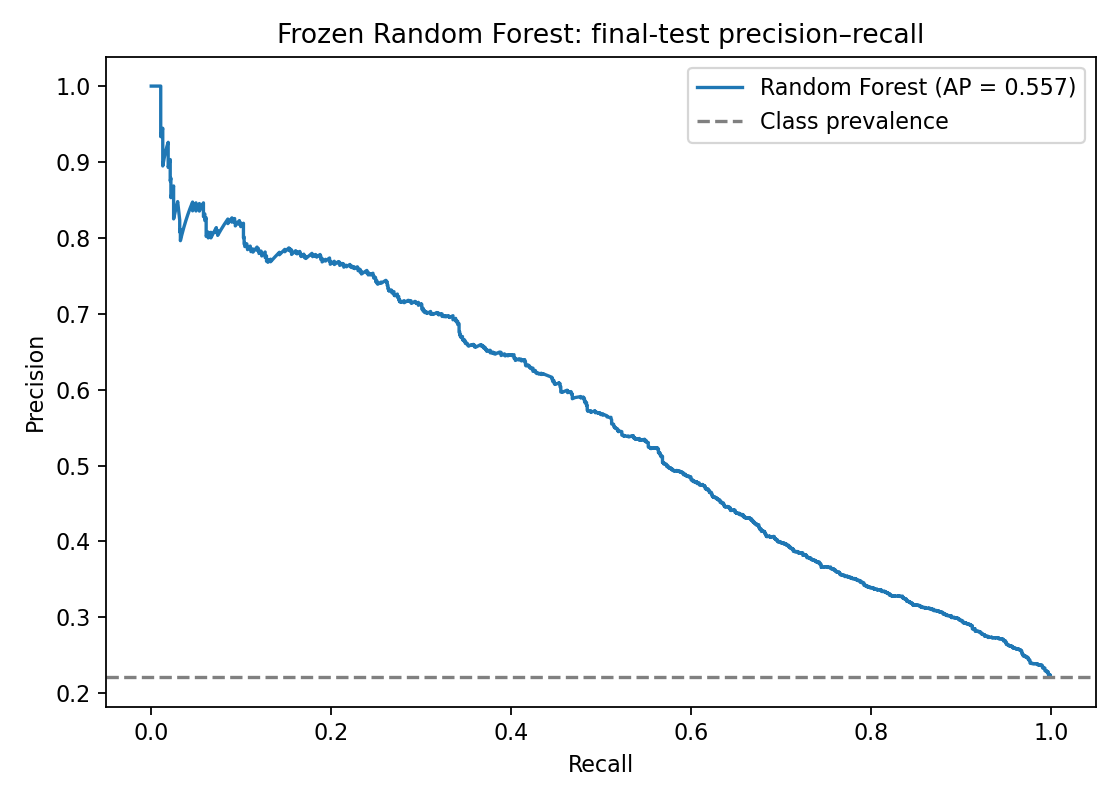

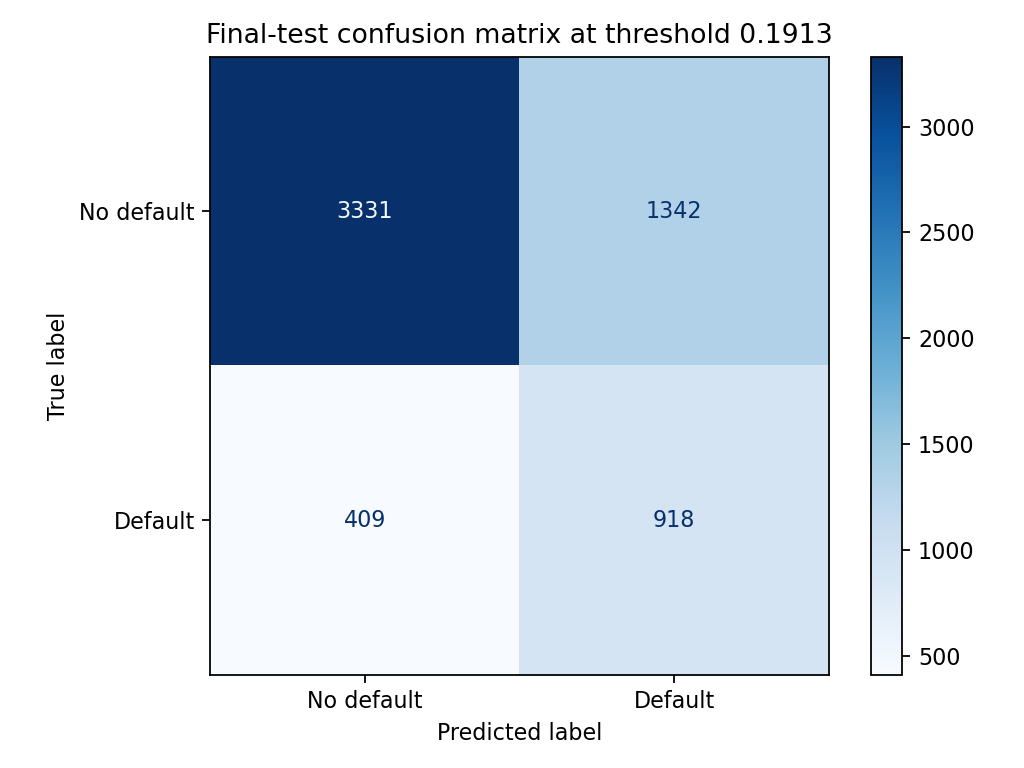

In [3]:
display(Image(filename=str(FIGURES / 'day7_final_test_roc.png')))
display(Image(filename=str(FIGURES / 'day7_final_test_precision_recall.png')))
display(Image(filename=str(FIGURES / 'day7_final_test_confusion_matrix.png')))

## Validation-to-test comparison

In [4]:
comparison

,metric,validation,final_test,final_minus_validation
0,roc_auc,0.771917,0.779397,0.007480
1,average_precision,0.539980,0.557033,0.017054
2,precision_at_frozen_threshold,0.410880,0.406195,-0.004685
3,recall_at_frozen_threshold,0.700075,0.691786,-0.008289
4,f1_at_frozen_threshold,0.517837,0.511848,-0.005989
5,false_positive_rate,0.285042,0.287182,0.002140
6,proportion_flagged,0.376833,0.376667,-0.000167


Final-test recall is below 70%, but the 70% requirement was a validation target rather than a test guarantee. The frozen model, preprocessing and threshold remain unchanged. These results are a held-out historical assessment, not evidence of production lending suitability, causality, fairness certification or regulatory compliance.